# Tutorial 7: A Bayesian Inverse Problem - Inferring ocean loads from GRACE data

## Setup

We begin by importing the necessary components from `pyslfp`, `pygeoinf`, and other standard libraries. We will also initialize our `FingerPrint` model, which provides the underlying physics.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random
import pyslfp as sl
import pygeoinf as inf
import cartopy.crs as ccrs

# Initialize the core fingerprint model - lower lmax to reduce calculation times for this tutorial.
fp = sl.FingerPrint(
    lmax=128,
    earth_model_parameters=sl.EarthModelParameters.from_standard_non_dimensionalisation(),
)
fp.set_state_from_ice_ng()

## Tutorial Context

This tutorial builds upon the framework established in **Tutorial 5**, where we performed a Bayesian inversion to infer ice melt patterns from tide gauge observations. Here, we apply the same mathematical and computational approach, but with two key differences:

1. **Data Source**: Instead of using sparse tide gauge measurements, we use **GRACE spherical harmonic coefficient observations**, which provide global coverage of the gravity field changes.

2. **Physical Process**: Rather than inferring **ice thickness changes** (as in Tutorial 5), we focus on inferring **ocean thickness changes** - essentially changes in ocean mass distribution. This represents a different physical process but uses the same underlying sea-level fingerprint physics.

The core mathematical framework remains identical: we solve a Bayesian inverse problem to find the posterior distribution of the unknown field, and then extract both the posterior expectation (our best estimate) and uncertainty quantification. The use of preconditioning to accelerate the iterative solution is also carried forward from the previous tutorial.

In [2]:
# Define the model space for the unknown ocean thickness change
order = 2.0
scale_km = 500.0
scale = scale_km * 1000 / fp.length_scale

model_space = inf.symmetric_space.sphere.Sobolev(
    fp.lmax, order, scale, radius=fp.mean_sea_floor_radius
)

In [3]:
# Maps scalar-fields on sphere to be non-zero only over the oceans.
op1 = sl.ocean_projection_operator(fp, model_space)

# Maps an ocean thickness change to the corresponding load.
def ocean_thickness_change_to_load_operator(finger_print, load_space):

    def mapping(ocean_thickness_change):
        return finger_print.water_density * ocean_thickness_change

    l2_load_space = sl.operators.underlying_space(load_space)

    l2_operator = inf.LinearOperator.self_adjoint(l2_load_space, mapping)

    return inf.LinearOperator.from_formally_self_adjoint(load_space, l2_operator) 

op2 = ocean_thickness_change_to_load_operator(fp, model_space)

# Maps a direct load to the full response. 
op3 = fp.as_sobolev_linear_operator(order, scale, rtol=1e-9)

# observation_degree is the truncation degree for the spherical harmonic coefficient observations
observation_degree = 20
op4 = sl.operators.grace_operator(op3.codomain, observation_degree)

# Form the forward operator by composition. 
A = op4 @ op3 @ op2 @ op1
data_space = A.codomain

# Form also a mapping from the model space to the sea level field for convenience. 
P = op3.codomain.subspace_projection(0)
A_sl = P @ op3 @ op2 @ op1

In [4]:
# Define the data error statistics
grace_data_std_dev_m = 0.0005
grace_data_std_dev = grace_data_std_dev_m / fp.length_scale
data_error_measure = inf.GaussianMeasure.from_standard_deviation(
    data_space, grace_data_std_dev
)

# Bundle everything into a forward problem object
forward_problem = inf.LinearForwardProblem(
    A, data_error_measure=data_error_measure
)

In [5]:
# Set the initial model prior measure
pointwise_std_m = 0.1
pointwise_std = pointwise_std_m / fp.length_scale
initial_model_prior_measure = model_space.point_value_scaled_heat_kernel_gaussian_measure(scale, pointwise_std)

# Transform so that ocean thickness change non-zero only over current oceans.    
model_prior_measure = initial_model_prior_measure.affine_mapping(operator=op1)

# --- Generate the synthetic ground truth and noisy data ---
model_true, data = forward_problem.synthetic_model_and_data(model_prior_measure)

In [6]:
# Repeat the set up of the forward problem, but now using a lower lmax
lmax_precon = 64

fp_precon = sl.FingerPrint(
    lmax=lmax_precon,
    earth_model_parameters=sl.EarthModelParameters.from_standard_non_dimensionalisation(),
)
fp_precon.set_state_from_ice_ng()

model_space_precon = inf.symmetric_space.sphere.Sobolev(
    fp_precon.lmax, order, scale, radius=fp_precon.mean_sea_floor_radius
)

op1_precon = sl.ocean_projection_operator(fp_precon, model_space_precon)
op2_precon = ocean_thickness_change_to_load_operator(fp_precon, model_space_precon)
op3_precon = fp_precon.as_sobolev_linear_operator(order, scale, rtol=1e-9)
op4_precon = sl.operators.grace_operator(op3_precon.codomain, observation_degree)
A_precon = op4_precon @ op3_precon @ op2_precon @ op1_precon

initial_model_prior_measure_precon = model_space_precon.point_value_scaled_heat_kernel_gaussian_measure(scale, pointwise_std)
model_prior_measure_precon = initial_model_prior_measure_precon.affine_mapping(operator=op1_precon)

forward_problem_precon = inf.LinearForwardProblem(
    A_precon, data_error_measure=data_error_measure
)

Having formed the reduced-degree problem, we can set up the necessary Bayesian inverse problems, extract the approximate normal operator for preconditioning, and then solve the full problem iteratively. Note that running this calculation at degree 256 will still take several minutes, but without preconditioning this would be substantially greater. 

In [7]:
# Set up the inversion for the preconditioning system
bayesian_inversion_precon = inf.LinearBayesianInversion(forward_problem_precon, model_prior_measure_precon)

# Get the normal operator for the preconditioning system.
normal_operator_precon = bayesian_inversion_precon.normal_operator

# Form its inverse using direct matrix inversion and wrap as a LinearOperator.
print("Forming the preconditioner by direct inversion...")
matrix_precon = normal_operator_precon.matrix(dense=True)
inverse_matrix_precon = np.linalg.pinv(matrix_precon) 
inverse_normal_operator_precon = inf.LinearOperator.from_matrix(
    normal_operator_precon.domain,
    normal_operator_precon.codomain,
    inverse_matrix_precon
)

# Set up the Bayesian inversion method
bayesian_inversion = inf.LinearBayesianInversion(forward_problem, model_prior_measure)

# Solve for the posterior distribution
print("Solving the linear system...")
model_posterior_measure = bayesian_inversion.model_posterior_measure(
    data, inf.CGMatrixSolver(), preconditioner= inverse_normal_operator_precon
)

# Get the posterior expectation
model_posterior_expectation = model_posterior_measure.expectation

# print out the total number of calls to the fingerpint solver - one will be for generating the synthetic data. 
print(f'Number of solutions of the fingerprint problem = {fp.solver_counter}')

Forming the preconditioner by direct inversion...
Solving the linear system...
Number of solutions of the fingerprint problem = 24


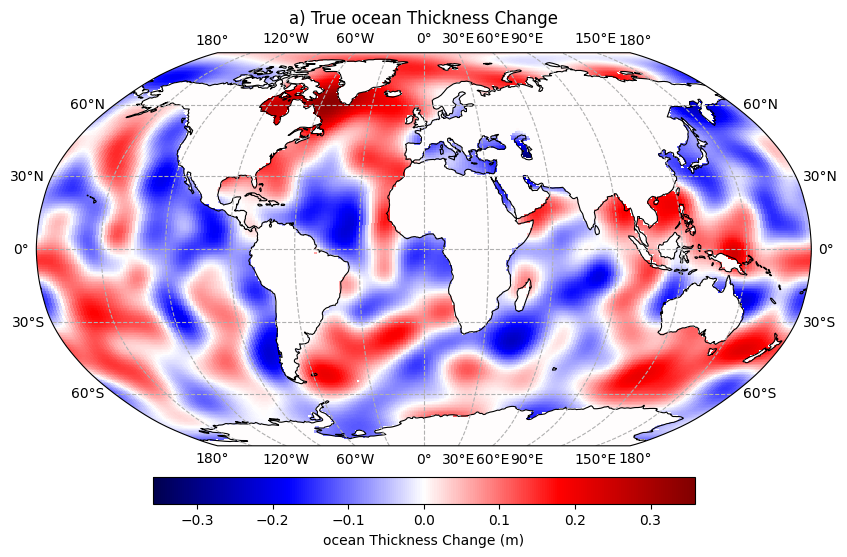

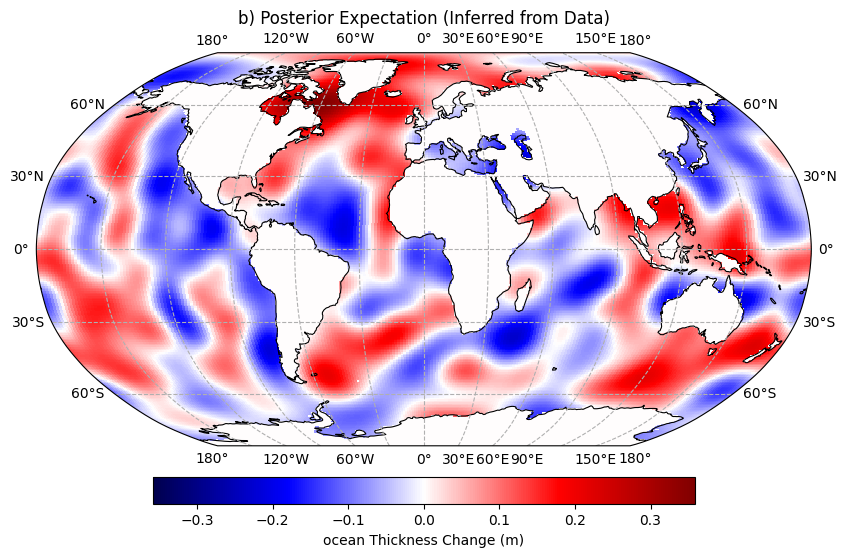

In [20]:
# --- Calculate a shared, symmetric color scale for the ocean thickness plots ---
max_abs_ocean_change = np.nanmax(
    np.abs(
        np.concatenate([
            (model_true).data.flatten(),
            (model_posterior_expectation).data.flatten()
        ])
    )
) * fp.length_scale

# --- Plot 1: The "Ground Truth" Model ---
fig1, ax1, im1 = sl.plot(
    model_true * fp.length_scale,
    coasts=True,
    cmap="seismic",
    vmin=-max_abs_ocean_change,
    vmax=max_abs_ocean_change
)
ax1.set_title("a) True ocean Thickness Change")
fig1.colorbar(im1, ax=ax1, orientation="horizontal", pad=0.05, shrink=0.7, label="ocean Thickness Change (m)")


# --- Plot 2: The Posterior Expectation (Our Best Estimate) ---
fig2, ax2, im2 = sl.plot(
    model_posterior_expectation  * fp.length_scale,
    coasts=True,
    cmap="seismic",
    vmin=-max_abs_ocean_change,
    vmax=max_abs_ocean_change
)
ax2.set_title("b) Posterior Expectation (Inferred from Data)")

fig2.colorbar(im2, ax=ax2, orientation="horizontal", pad=0.05, shrink=0.7, label="ocean Thickness Change (m)")
plt.show()

## Regional Analysis: North Atlantic Ocean Mass Change

Following the approach from Tutorial 5 where we examined global mean sea level (GMSL), we now focus on a regional quantity: the average ocean thickness change over the North Atlantic Ocean. This demonstrates how the posterior distribution can be projected onto specific regions of interest using simple geographic masks.

We will create a rectangular mask covering the North Atlantic region (approximately 60°W to 10°W, 10°N to 50°N) and use it to extract both the true regional average and our posterior estimate, along with full uncertainty quantification.

In [32]:
# Create a simple North Atlantic mask
# North Atlantic region: 60°W to 10°W, 10°N to 50°N

# Define the North Atlantic bounds
lon_min = 300  # 60°W
lon_max = 330  # 10°W  
lat_min = 20.0   # 10°N
lat_max = 35.0   # 50°N

# Create the mask following the same pattern as altimetry_projection
lats, lons = np.meshgrid(fp.lats(), fp.lons(), indexing="ij")
ocean_mask = fp.ocean_function.data > 0
lat_mask = np.logical_and(lats >= lat_min, lats <= lat_max)
lon_mask = np.logical_and(lons >= lon_min, lons <= lon_max)
geographic_mask = np.logical_and(lat_mask, lon_mask)

# Create the North Atlantic mask as an SHGrid
from pyshtools import SHGrid
north_atlantic_mask_data = np.where(np.logical_and(ocean_mask, geographic_mask), 1.0, 0.0)
north_atlantic_weighting_function = SHGrid.from_array(north_atlantic_mask_data, grid=fp.grid)

# Normalize the weighting function by its total integral
normalization = fp.integrate(north_atlantic_weighting_function)
north_atlantic_weighting_function = north_atlantic_weighting_function / normalization

# Form the mapping to North Atlantic average
B_north_atlantic = sl.averaging_operator(model_space, [north_atlantic_weighting_function])

# Get the true North Atlantic average
north_atlantic_true = B_north_atlantic(model_true)

# Push forward the posterior to the North Atlantic space
north_atlantic_posterior_measure = model_posterior_measure.affine_mapping(operator=B_north_atlantic)

# Get the measure as a scipy distribution
north_atlantic_distribution = north_atlantic_posterior_measure.as_multivariate_normal()

print(f"True North Atlantic ocean thickness change: {north_atlantic_true[0] * fp.length_scale:.6f} m")
print(f"Posterior mean estimate: {north_atlantic_distribution.mean[0] * fp.length_scale:.6f} m")
print(f"Posterior standard deviation: {np.sqrt(north_atlantic_distribution.cov[0, 0]) * fp.length_scale:.6f} m")

True North Atlantic ocean thickness change: -0.068109 m
Posterior mean estimate: -0.060916 m
Posterior standard deviation: 0.012723 m


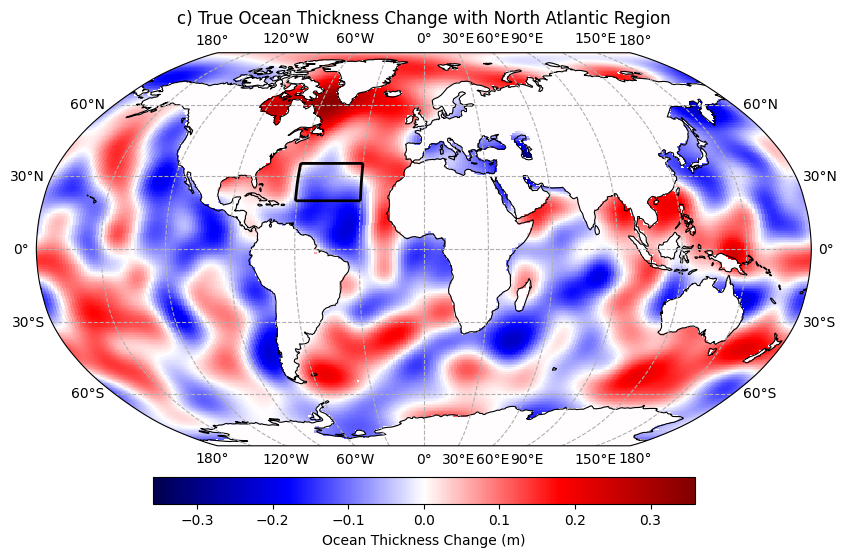

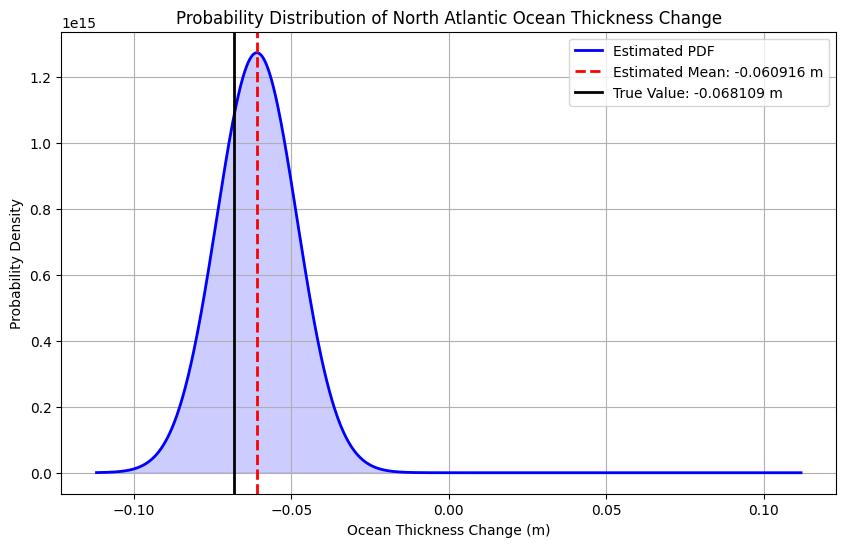

In [ ]:
# Plot the true field with North Atlantic region outlined
fig3, ax3, im3 = sl.plot(
    model_posterior_expectation * fp.length_scale,
    coasts=True,
    cmap="seismic",
    vmin=-max_abs_ocean_change,
    vmax=max_abs_ocean_change
)
ax3.set_title("c) True Ocean Thickness Change with North Atlantic Region")

# Add contour outline where the North Atlantic mask is active
lats_2d, lons_2d = np.meshgrid(fp.lats(), fp.lons(), indexing="ij")
mask_active = north_atlantic_weighting_function.data > 0
ax3.contour(lons_2d, lats_2d, mask_active.astype(float), levels=[0.5], 
           colors='black', linewidths=2, transform=ccrs.PlateCarree())

fig3.colorbar(im3, ax=ax3, orientation="horizontal", pad=0.05, shrink=0.7, label="Ocean Thickness Change (m)")

# Plot the probability distribution for North Atlantic ocean thickness change
north_atlantic_mean = north_atlantic_distribution.mean[0] * fp.length_scale
north_atlantic_std = np.sqrt(north_atlantic_distribution.cov[0, 0]) * fp.length_scale
x_max = np.max([np.abs(north_atlantic_mean - 4 * north_atlantic_std), 
                np.abs(north_atlantic_mean + 4 * north_atlantic_std)])
x_axis = np.linspace(-x_max, x_max, 1000)
pdf_values = north_atlantic_distribution.pdf(x_axis / fp.length_scale) * fp.length_scale

plt.figure(figsize=(10, 6))
plt.plot(x_axis, pdf_values, color='blue', lw=2, label='Estimated PDF')
plt.fill_between(x_axis, pdf_values, color='blue', alpha=0.2)
plt.axvline(north_atlantic_mean, color='red', linestyle='--', lw=2, 
           label=f'Estimated Mean: {north_atlantic_mean:.6f} m')
plt.axvline(north_atlantic_true[0] * fp.length_scale, color='black', linestyle='-', lw=2, 
           label=f'True Value: {north_atlantic_true[0] * fp.length_scale:.6f} m')
plt.title('Probability Distribution of North Atlantic Ocean Thickness Change')
plt.xlabel('Ocean Thickness Change (m)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

In this tutorial, we have successfully adapted the Bayesian inversion framework from Tutorial 5 to work with GRACE data for inferring ocean mass changes. The key achievements include:

* **Data Adaptation**: We demonstrated how to modify the forward operator to work with GRACE spherical harmonic observations instead of sparse tide gauge measurements.
* **Physical Process**: We showed how the same framework can be applied to ocean thickness changes rather than ice thickness changes, with appropriate modifications to the load operators.
* **Computational Efficiency**: We successfully implemented preconditioning using a lower-resolution problem to accelerate the solution of the full-resolution inverse problem.
* **Regional Analysis**: We extended the global analysis to focus on regional quantities using Gaussian averaging functions, specifically examining ocean thickness changes in the North Atlantic.

The results demonstrate that GRACE observations provide sufficient information to recover both the large-scale patterns of ocean thickness change and regional averages with well-quantified uncertainties. This methodology forms the foundation for more complex applications involving real GRACE data and multiple physical processes.